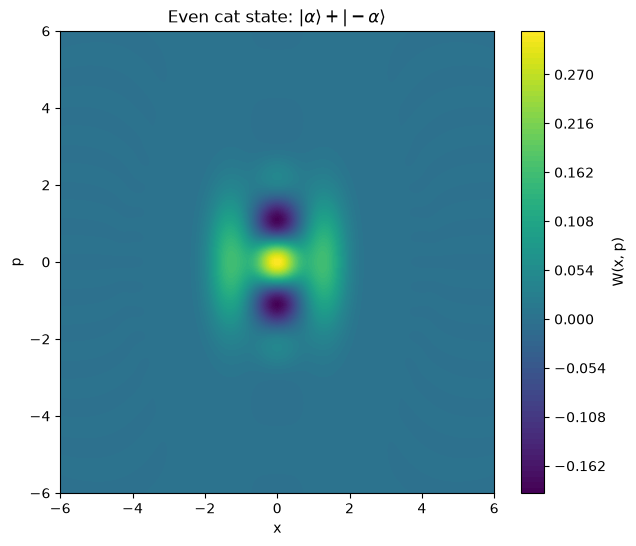

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Fock-space cutoff
N = 40
# Cat amplitude
alpha = 1.5
# squeezing 
r = 0.5

vaccuum = qt.coherent(N,0)
# Construct the coherent states |alpha> and |-alpha>
ket_plus = qt.coherent(N, alpha)
ket_minus = qt.coherent(N, -alpha)

# Even cat state
cat = (ket_plus + ket_minus).unit()

# squeezing operator
S = qt.squeeze(N,r)

#squeezed cat
SC = S*cat


# two cats
cat2 = qt.tensor(SC,SC)

# Phase-space grid
xvec = np.linspace(-6, 6, 300)
pvec = np.linspace(-6, 6, 300)

# Calculate Wigner function
W = qt.wigner(SC, xvec, pvec)

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(xvec, pvec, W, levels=100)
plt.colorbar(label="W(x, p)")
plt.xlabel("x")
plt.ylabel("p")
plt.title(r"Even cat state: $|\alpha\rangle + |-\alpha\rangle$")
plt.show()

In [3]:
# beamsplitter on 2 squeezed cats 

a1 = qt.tensor(qt.destroy(N), qt.qeye(N))
a2 = qt.tensor(qt.qeye(N), qt.destroy(N))

# 50/50 beam splitter angle (theta = pi/4, phi = pi/2)
theta = np.pi / 4
phi = np.pi / 2

# Interaction operator for the beam splitter
H_bs = theta * (a1.dag() * a2 * np.exp(-1j * phi) + a1 * a2.dag() * np.exp(1j * phi))
U_bs = H_bs.expm()  # Unitary operator

# input state 
psi0 = qt.tensor(cat,cat)

# apply beamsplitter
psi_out = U_bs * psi0

In [9]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [11]:
from protocol.states import make_cat, make_squeezed_cat

# Fock-space cutoff
N = 40
# Cat amplitude
alpha = 1.5
# squeezing 
r = 0.5

cat = make_cat(N, alpha)
squeezed_cat = make_squeezed_cat(N, alpha, r)

print(cat.norm())
print(squeezed_cat.norm())

1.0
1.0


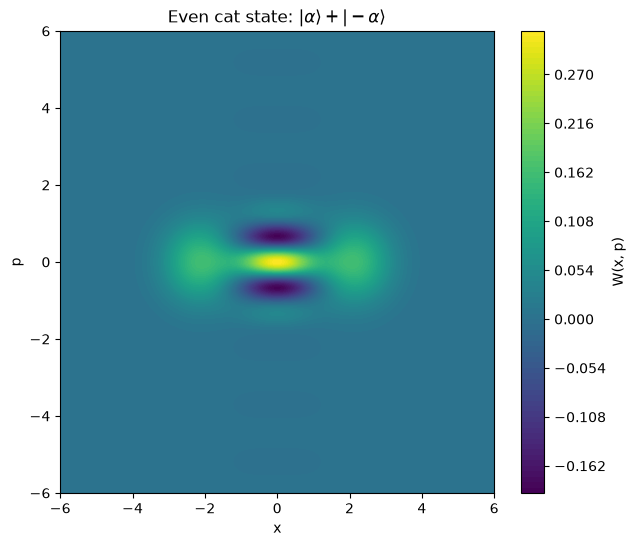

In [12]:
# Phase-space grid
xvec = np.linspace(-6, 6, 300)
pvec = np.linspace(-6, 6, 300)

# Calculate Wigner function
W = qt.wigner(cat, xvec, pvec)

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(xvec, pvec, W, levels=100)
plt.colorbar(label="W(x, p)")
plt.xlabel("x")
plt.ylabel("p")
plt.title(r"Even cat state: $|\alpha\rangle + |-\alpha\rangle$")
plt.show()